## Matching with "SDG Indicator 11.2.1: Urban Access to Public Transport, 2023 Release"

https://www.earthdata.nasa.gov/data/catalog/sedac-ciesin-sedac-sdgi-uapt-2023-2023.00

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [197]:
cities_ipcc = pd.read_json('../data/urban-wedge/cities.json')

In [198]:
ucdb = gpd.read_parquet('../data/GHS_UCDB_GLOBE_R2024A.parquet')
cities_ipcc = pd.merge(cities_ipcc, ucdb[['ID_UC_G0', 'geometry']], left_on='id', right_on='ID_UC_G0', how='left')
cities_ipcc = gpd.GeoDataFrame(cities_ipcc, geometry='geometry', crs=ucdb.crs)


In [199]:
gdf_pt_access = gpd.read_file('../data/urban-wedge/sdgi-11-2-1-urban-access-public-transport-2023-shp')

In [200]:
country_rename = {
    'Cape Verde': 'Cabo Verde',
    'Czech Republic': 'Czechia',
    'Macedonia': 'North Macedonia',
    'Mexico': 'México',
    'Palestina': 'Palestine',
    'Republic of Congo': 'Republic of the Congo'
}
set(gdf_pt_access['CTR_MN_NM'].replace(country_rename)).difference(set(cities_ipcc['country']))

set()

In [93]:
set(cities_ipcc['country']).difference(set(gdf_pt_access['CTR_MN_NM'].replace(country_rename)))


{'Aruba',
 'French Guiana',
 'Martinique',
 'Mayotte',
 'Northern Cyprus',
 'Réunion',
 'Samoa',
 'Tonga',
 'Vanuatu'}

### Matching based on city + country name (as sdgi also uses UCDB, but from 2015) (DEPRECATED)

In [141]:
cities_ipcc['city_country'] = cities_ipcc['name'] + ', ' + cities_ipcc['country']
gdf_pt_access['UC_NM_MN'] = gdf_pt_access['UC_NM_MN'].replace('N/A', np.nan)
gdf_pt_access['city_country'] = gdf_pt_access['UC_NM_MN'] + ', ' + gdf_pt_access['CTR_MN_NM'].replace(country_rename)
cities_w_pt = pd.merge(cities_ipcc, gdf_pt_access.dropna(subset='UC_NM_MN'), on='city_country', how='inner')
cities_w_pt['distance'] = cities_w_pt['geometry_x'].distance(cities_w_pt['geometry_y'].to_crs(cities_ipcc.crs))
gdf_pt_access_leftover = gdf_pt_access[~gdf_pt_access['city_country'].isin(cities_w_pt['city_country'])]
cities_leftover_pt = cities_ipcc[~cities_ipcc['city_country'].isin(cities_w_pt['city_country'])]
print(f"Leftover {len(gdf_pt_access_leftover)}/{len(gdf_pt_access)} entries without matches.")
print(f"Leftover {len(cities_leftover_pt)}/{len(cities_ipcc)} cities without PT matches.")


Leftover 5110/13135 entries without matches.
Leftover 3452/11422 cities without PT matches.


country
China            245
India            124
United States     21
Nigeria            8
Indonesia          7
Philippines        6
Ethiopia           5
Bangladesh         4
Vietnam            3
México             2
Brazil             2
Mozambique         1
Yemen              1
Pakistan           1
Name: count, dtype: int64

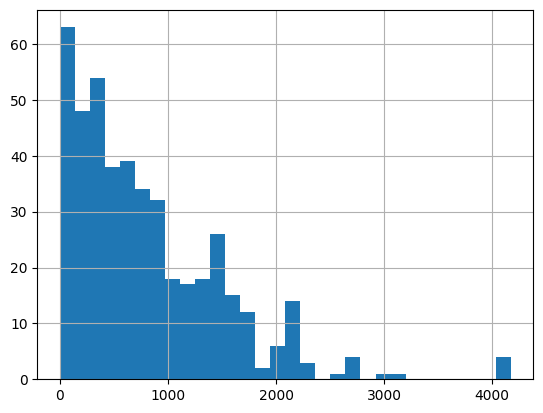

In [148]:
cities_w_pt[cities_w_pt['distance'] > 0]['distance'].div(1000).hist(bins=30)
cities_w_pt[cities_w_pt['distance'] > 10000]['country'].value_counts()

In [ ]:

ex = cities_w_pt[cities_w_pt['distance'] > 100000].sample(1)
m = ex[['geometry_x']].set_geometry('geometry_x').explore()
ex[['geometry_y']].set_geometry('geometry_y').explore(m=m, color='red')

**Take-away**: Matching on city name and country not reliable as there are too many cities with the same name in one country.

### Matching based on spatial overlap of city area

In [203]:
import geopandas as gpd
import pandas as pd

def merge_by_best_iou(gdf_source, gdf_target, value_col='SDG1121pct',
                      id_col='id', iou_threshold=0.25):
    """
    For each polygon in gdf_source, find the polygon in gdf_target with the
    largest IoU. If IoU >= threshold, copy gdf_target's value_col and id_col
    into that row of gdf_source.

    gdf_source: receives value_col and id_col from its best IoU match.
    gdf_target: holds SDG1121pct and the identifier column.
    """
    if gdf_source.crs != gdf_target.crs:
        gdf_target = gdf_target.to_crs(gdf_source.crs)

    source = gdf_source.reset_index(drop=True).copy()
    target = gdf_target.reset_index(drop=True).copy()

    # Spatial join: only consider overlapping pairs
    joined = gpd.sjoin(
        source[['geometry']].reset_index().rename(columns={'index': 'source_idx'}),
        target[['geometry', value_col, id_col]].reset_index().rename(columns={'index': 'target_idx'}),
        how='inner',
        predicate='intersects'
    )

    # Compute IoU per candidate pair
    def compute_iou(row):
        g_src = source.geometry.iloc[row['source_idx']]
        g_tgt = target.geometry.iloc[row['target_idx']]
        inter = g_src.intersection(g_tgt).area
        union = g_src.union(g_tgt).area
        return inter / union if union > 0 else 0.0

    joined['iou'] = joined.apply(compute_iou, axis=1)

    # For each source polygon, keep only its single best target match
    best = (joined.sort_values('iou', ascending=False)
                  .drop_duplicates('source_idx'))
    best = best[best['iou'] >= iou_threshold]

    # Write target's value_col and id_col into the matched source rows
    source[value_col] = pd.NA
    source[f'matched_{id_col}'] = pd.NA
    source['best_iou'] = pd.NA

    source.loc[best['source_idx'].values, value_col] = best[value_col].values
    source.loc[best['source_idx'].values, f'matched_{id_col}'] = best[id_col].values
    source.loc[best['source_idx'].values, 'best_iou'] = best['iou'].values

    return source


gdf_pt_access['UC_NM_MN'] = gdf_pt_access['UC_NM_MN'].replace('N/A', np.nan)
gdf_pt_access['city_country'] = gdf_pt_access['UC_NM_MN'] + ', ' + gdf_pt_access['CTR_MN_NM'].replace(country_rename)
cities_ipcc['city_country'] = cities_ipcc['name'] + ', ' + cities_ipcc['country']
gdf_pt_access['SDG1121pct'] = gdf_pt_access['SDG1121pct'].replace(-9999.0, pd.NA)
result = merge_by_best_iou(cities_ipcc, gdf_pt_access, value_col='SDG1121pct', id_col='city_country', iou_threshold=0.25)

In [ ]:
result['name_matches'] = (result['name'] + ', ' + result['country']) == result['matched_city_country']
print("Proportion of matches:")
print(result['matched_city_country'].notna().mean().round(2))
print("Proportion of matches with identical city + country name:")
print(result['name_matches'].mean().round(2))

print("PT index coverage")
print((result['SDG1121pct'] > 0).mean().round(2))

Proportion of matches:
0.79
Proportion of matches with identical city + country name:
0.67
PT index coverage
0.44


In [ ]:
# result[['id', 'name', 'country', 'region', 'type', 'SDG1121pct', 'matched_city_country', 'best_iou', 'name_matches']].rename(columns={'best_iou': 'iou'}).to_csv('../data/urban-wedge/cities_with_pt_access.csv', index=False)
# result.drop(columns=['ID_UC_G0', 'city_country']).to_parquet('../data/urban-wedge/cities_full_with_pt_access.parquet', index=False)

### NaN imputation

In [204]:
import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree


def normalize_popdens(gdf, popdens_col='pop_density', country_col='country',
                     region_col='region', out_col='pop_density_rank',
                     min_country_size=5):
    """
    Add a percentile-rank column for population density in [0, 1].

    Normalization scope:
      - If a country has > min_country_size cities, rank within the country.
      - Otherwise, rank within the country's region (broader pool).

    Robust to outliers and to differences in distribution shape between frames
    (e.g. whole-area vs built-up-only density).
    """
    out = gdf.copy()
    x = out[popdens_col].astype(float)

    # Decide grouping per row: country if country has enough cities, else region
    country_size = out.groupby(country_col)[popdens_col].transform('size')
    use_country = country_size > min_country_size

    group = np.where(use_country, out[country_col].astype(str),
                                  'region::' + out[region_col].astype(str))
    group = pd.Series(group, index=out.index)

    out[out_col] = x.groupby(group).rank(pct=True)
    out['_norm_scope'] = np.where(use_country, 'country', 'region')

    return out

def gwr_infill_missing(
    gdf_source,
    gdf_target,
    value_col='SDG1121pct',
    country_col='country',
    popdens_rank_col='pop_density_rank',
    k=5,
    power=2,
    pct_window=0.15,
):
    """
    Infill missing value_col in gdf_source using an inverse-distance-weighted
    mean of the k nearest rows in gdf_target that:
      - have a non-missing value_col,
      - share the same country_col,
      - have popdens_rank within +/- pct_window of the source row's popdens_rank.

    pct_window is in percentile-rank units (0..1), e.g. 0.15 = +/-15 percentile points.
    """
    if gdf_source.crs != gdf_target.crs:
        gdf_target = gdf_target.to_crs(gdf_source.crs)

    out = gdf_source.copy()
    tgt = gdf_target.copy()

    # Provenance
    if 'infill_source' not in out.columns:
        out['infill_source'] = np.where(out[value_col].notna(), 'iou', 'unfilled')
    out['infill_n_neighbors'] = pd.NA

    # Centroids for distance
    s_cent = out.geometry.centroid
    t_cent = tgt.geometry.centroid
    out['_x'], out['_y'] = s_cent.x.values, s_cent.y.values
    tgt['_x'], tgt['_y'] = t_cent.x.values, t_cent.y.values

    # Only target rows with a value can be donors
    tgt_donors_all = tgt[tgt[value_col].notna()].copy()

    for country, donors in tgt_donors_all.groupby(country_col):
        receivers = out[(out[country_col] == country) & (out[value_col].isna())]
        if receivers.empty or donors.empty:
            continue

        donor_xy = donors[['_x', '_y']].to_numpy()
        donor_vals = donors[value_col].to_numpy(dtype=float)
        donor_rank = donors[popdens_rank_col].to_numpy(dtype=float)
        tree = cKDTree(donor_xy)

        for r_idx, r in receivers.iterrows():
            r_rank = r[popdens_rank_col]
            if pd.isna(r_rank):
                continue

            lo, hi = r_rank - pct_window, r_rank + pct_window
            mask = (donor_rank >= lo) & (donor_rank <= hi)
            if not mask.any():
                continue

            # Query more than k, then filter by the percentile window
            n_candidates = min(len(donor_xy), max(k * 4, k))
            dists, inds = tree.query([r['_x'], r['_y']], k=n_candidates)
            dists = np.atleast_1d(dists)
            inds = np.atleast_1d(inds)

            keep = mask[inds]
            dists, inds = dists[keep], inds[keep]
            if len(inds) == 0:
                continue

            dists, inds = dists[:k], inds[:k]
            vals = donor_vals[inds]

            eps = 1e-9
            w = 1.0 / (dists ** power + eps)
            w /= w.sum()

            out.at[r_idx, value_col] = float(np.sum(w * vals))
            out.at[r_idx, 'infill_source'] = 'gwr'
            out.at[r_idx, 'infill_n_neighbors'] = len(inds)

    out = out.drop(columns=['_x', '_y'])
    return out

gdf_pt_access['region'] = gdf_pt_access['CTR_MN_NM'].replace(country_rename).map(cities_ipcc.drop_duplicates(subset='country').set_index('country')['region'])
gdf_pt_access['population_density'] = gdf_pt_access['Total_POP'] / gdf_pt_access.to_crs(cities_ipcc.crs).area.div(1e6)
gdf_pt_access_norm = normalize_popdens(gdf_pt_access.rename(columns={'CTR_MN_NM': 'country'}), popdens_col='population_density',
                            country_col='country',
                            region_col='region',

                            out_col='pop_density_rank')
result_norm = normalize_popdens(result, popdens_col='population_density',
                            country_col='country',
                            region_col='region',
                            out_col='pop_density_rank')


result = gwr_infill_missing(result_norm, gdf_pt_access_norm,
                            value_col='SDG1121pct',
                            country_col='country',
                            popdens_rank_col='pop_density_rank',
                            k=5,
                            power=2,
                            pct_window=0.15)

In [208]:
result['name_matches'] = (result['name'] + ', ' + result['country']) == result['matched_city_country']
print("Proportion of matches:")
print(result['matched_city_country'].notna().mean().round(2))
print("Proportion of matches with identical city + country name:")
print(result['name_matches'].mean().round(2))

print("PT index coverage")
print((result['SDG1121pct'] > 0).mean().round(2))
print((result[result['infill_source'] == 'gwr']['SDG1121pct'] > 0).mean().round(2))
print((result['infill_source'].value_counts(normalize=True).round(2)))

Proportion of matches:
0.79
Proportion of matches with identical city + country name:
0.67
PT index coverage
0.95
1.0
infill_source
gwr         0.52
iou         0.44
unfilled    0.05
Name: proportion, dtype: float64


In [226]:
result[['id', 'name', 'country', 'region', 'type', 'SDG1121pct', 'matched_city_country', 'best_iou', 'infill_source', 'name_matches']].rename(columns={'best_iou': 'iou'}).to_csv('../data/urban-wedge/cities_with_pt_access.csv', index=False)

In [227]:
result.drop(columns=['pop_density_rank', 'infill_n_neighbors', '_norm_scope', 'ID_UC_G0', 'city_country']).to_parquet('../data/urban-wedge/cities_full_with_pt_access.parquet', index=False)

### Visualization to sanity check NaN imputation

In [225]:
import numpy as np
import matplotlib as mpl
from lonboard import Map, ScatterplotLayer

# Ensure point geometries for ScatterplotLayer
points = result[['SDG1121pct', 'id', 'name', 'country', 'region', 'type', 'best_iou', 'infill_source', 'name_matches', '_norm_scope', 'pop_density_rank', 'geometry']].copy()
def fmt(s, decimals):
    return s.map(lambda v: f"{v:.{decimals}f}" if pd.notna(v) else "")

points['SDG1121pct']       = fmt(pd.to_numeric(points['SDG1121pct'],       errors='coerce'), 1)
points['best_iou']         = fmt(pd.to_numeric(points['best_iou'],         errors='coerce'), 2)
points['pop_density_rank'] = fmt(pd.to_numeric(points['pop_density_rank'], errors='coerce'), 2)
points['geometry'] = points.centroid.to_crs(4326)


iou_rows      = points[points['infill_source'] == 'iou']
gwr_rows      = points[points['infill_source'] == 'gwr']
unfilled_rows = points[points['infill_source'] == 'unfilled']

cmap = mpl.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=0, vmax=100)

def values_to_rgb(values):
    rgba = cmap(norm(values.astype(float)))
    return (rgba[:, :3] * 255).astype(np.uint8)

iou_colors = values_to_rgb(iou_rows['SDG1121pct'].values)
gwr_colors = values_to_rgb(gwr_rows['SDG1121pct'].values)

# IoU: small, solid, no outline — "observed"
layer_iou = ScatterplotLayer.from_geopandas(
    iou_rows,
    get_fill_color=iou_colors,
    get_radius=5000,
    opacity=0.9,
    stroked=False,
)

# GWR: larger, lower opacity fill, thick magenta-ish outline — "estimated"
# Magenta sits opposite viridis on the color wheel, so the ring pops against
# every fill color in the ramp without competing with the data encoding.
layer_gwr = ScatterplotLayer.from_geopandas(
    gwr_rows,
    get_fill_color=gwr_colors,
    get_line_color=[220, 30, 180],   # magenta ring
    get_line_width=800,
    line_width_units='meters',
    get_radius=2500,
    opacity=0.45,                    # softer fill so the ring dominates
    stroked=True,
)

# Unfilled: hollow gray ring — "missing"
layer_unfilled = ScatterplotLayer.from_geopandas(
    unfilled_rows,
    get_fill_color=[0, 0, 0, 0],
    get_line_color=[80, 80, 80],
    get_line_width=500,
    line_width_units='meters',
    get_radius=2500,
    opacity=0.9,
    stroked=True,
)

m = Map(
    layers=[layer_unfilled, layer_gwr, layer_iou],
    basemap_style="https://basemaps.cartocdn.com/gl/voyager-gl-style/style.json",
    show_tooltip=True,
)
html_path = "cities_pt_access_infill_map.html"
m.to_html(html_path)

# Build a viridis gradient string for the colorbar
import matplotlib.colors as mcolors
stops = np.linspace(0, 1, 11)
gradient_stops = ", ".join(
    f"{mcolors.to_hex(cmap(s))} {int(s*100)}%" for s in stops
)

legend_html = f"""
<div style="
    position: fixed; bottom: 20px; left: 20px; z-index: 9999;
    background: rgba(255,255,255,0.95); padding: 12px 14px;
    border-radius: 6px; box-shadow: 0 2px 6px rgba(0,0,0,0.2);
    font-family: -apple-system, BlinkMacSystemFont, sans-serif;
    font-size: 12px; color: #222; min-width: 200px;">
  <div style="font-weight: 600; margin-bottom: 6px;">SDG 11.2.1 (%)</div>
  <div style="height: 12px; border-radius: 2px;
              background: linear-gradient(to right, {gradient_stops});"></div>
  <div style="display: flex; justify-content: space-between;
              margin-top: 2px; font-size: 11px; color: #555;">
    <span>0</span><span>50</span><span>100</span>
  </div>

  <div style="font-weight: 600; margin: 10px 0 6px 0;">Source</div>
  <div style="display: flex; align-items: center; margin-bottom: 4px;">
    <span style="display:inline-block; width:14px; height:14px;
                 border-radius:50%; background:#4a7c59; margin-right:8px;"></span>
    IoU match (observed)
  </div>
  <div style="display: flex; align-items: center; margin-bottom: 4px;">
    <span style="display:inline-block; width:14px; height:14px;
                 border-radius:50%; background:#4a7c59;
                 border: 3px solid rgb(220,30,180);
                 box-sizing: border-box; margin-right:8px;"></span>
    GWR estimate
  </div>
  <div style="display: flex; align-items: center;">
    <span style="display:inline-block; width:14px; height:14px;
                 border-radius:50%; background:transparent;
                 border: 2px solid #555; margin-right:8px;"></span>
    Unfilled (no match)
  </div>
</div>
"""

# Inject before </body>
with open(html_path, 'r') as f:
    html = f.read()
html = html.replace('</body>', legend_html + '\n</body>')
with open(html_path, 'w') as f:
    f.write(html)

/var/folders/jk/rndbblbs2fs0_symsqry30400000gn/T/ipykernel_55908/405415418.py:65: DeprecationWarning: `basemap_style` is deprecated and will be removed in 0.14. Use `basemap` instead.
  m = Map(
